In [3]:
import numpy as np
from scipy.special import comb
from scipy.integrate import *
from scipy.linalg import pinv, pinvh, expm

from opt_einsum import contract, contract_expression

import jax.numpy as jnp
from jax import jit
from functools import partial

from integrators import *

import matplotlib.pyplot as plt

from electron_integrals import *

from SemiDirectCI_jax import SemiDirectCI


Define functions

In [4]:
@jit
def Cb_to_y(C, b):
    return jnp.concatenate([C.flatten(), b.flatten()])

@partial(jit, static_argnums=(1,2,3))
def y_to_Cb(y, num_mctdhf_orbitals, num_spin_orbitals, num_slater_dets):
    C, b = jnp.split(y, [num_slater_dets])
    b = jnp.reshape(b, (num_spin_orbitals, num_mctdhf_orbitals))

    return C, b

@jit
def gram_schmidt(b):
    b = jnp.divide(b, jnp.sqrt(contract('ij, ij -> j', b.conj(), b, backend='jax')))
    for i in range(b.shape[1]):
        orto_adjustment = 0
        for j in range(0, i):
            orto_adjustment += jnp.dot(b[:, i], b[:, j])*b[:, j]

        b.at[:,i].add(-orto_adjustment)

    return b

@jit
def overlap_ortnorm(b):
    b = jnp.divide(b, jnp.sqrt(contract('ij, ij -> j', b.conj(), b, backend='jax')))
    u, _, vh = jnp.linalg.svd(b, full_matrices=False)
    return u@vh

@jit
def normalize_C(C):
    return jnp.divide(C, jnp.sqrt(C.T.conj()@C))

@partial(jit, static_argnums=(0,5))
def get_E(dCI, h, g, b, C, C_shape):
    bc = b.conj()
    h_1 = contract('jm, ij -> im', b, h, backend='jax')
    h_2 = contract('in, im -> nm', bc, h_1, backend='jax')

    g_2 = contract('jq, js, ij -> iqs', bc, b, g, backend='jax')
    g_3 = contract('ir, iqs -> iqrs', b, g_2, backend='jax')
    g_4 = contract('ip, iqrs -> pqrs', bc, g_3, backend='jax')

    return dCI.calculate_energy(jnp.reshape(C, C_shape), h_2, g_4)

Define number of electrons and orbitals

In [5]:
# Number of spatial orbitals
num_sinc_orbitals = 101
# Number of electrons
num_alpha_electrons = 1
num_beta_electrons = 1

Calculate electron integrals

In [6]:
def kinetic_energy_mels(i, j, dx):
    with np.errstate(divide='ignore'):
        return np.where(
            i==j,
            np.pi ** 2 / (6 * dx ** 2),
            (-1.0) ** (i_min_j := i - j) / (dx ** 2 * i_min_j **2),
        )

In [7]:
grid = np.linspace(-10, 10, num_sinc_orbitals)
x = grid
dx = np.abs(grid[1] - grid[0])
inds=np.arange(len(grid))

pot = lambda x, omega=0.25: 0.5 * omega**2 * x ** 2

t = kinetic_energy_mels(inds[:, None], inds[None, :], dx)

h = t + np.diag(pot(grid))

g = shielded_coulomb(grid[:, None], grid[None, :], kappa=1, a=0.25)

In [8]:
def xi(i, grid=grid, dx=dx):
    return np.sinc(((grid-grid[i])/dx))/np.sqrt(dx)

spf = np.array([xi(i) for i in range(num_sinc_orbitals)])

# Orbital equations

Define number of MCTDHF orbitals $(\{\ket{\phi_n(t)}\})$, initial b's (basis reduction coefficients),

$\ket{\phi_n(t)} = \sum_{k=1}^{N_b}b_{kn}(t)\ket{\psi_k}$,

and initial C's.


In [9]:
num_mctdhf_orbitals = 20
num_mctdhf_alpha_dets = int(comb(num_mctdhf_orbitals, num_alpha_electrons))
num_mctdhf_beta_dets = int(comb(num_mctdhf_orbitals, num_beta_electrons))
num_mctdhf_dets = num_mctdhf_alpha_dets*num_mctdhf_beta_dets
C_shape = (num_mctdhf_alpha_dets, num_mctdhf_beta_dets)


# Distributed vales
#b_init = np.zeros((num_spin_orbitals, num_mctdhf_orbitals))
#a = int(num_spin_orbitals/num_mctdhf_orbitals)
#for i in range(num_mctdhf_orbitals):
#    b_init[a*i:a*(i+1), i] = np.ones(a)

# Identity
#b_init=np.eye(num_spin_orbitals, num_mctdhf_orbitals)

# Generate random orthonormal vectors
rng = np.random.default_rng()
r = rng.random((num_sinc_orbitals, num_mctdhf_orbitals))
u, _, vh = np.linalg.svd(r, full_matrices=False)
b_init = (u@vh).astype(jnp.complex64)

#print(b_init)

# Ones as initial C
#C_init = np.ones((num_mctdhf_slater_dets), dtype=np.cdouble)

# Random initial C
C_init = rng.random(num_mctdhf_alpha_dets*num_mctdhf_beta_dets).astype(jnp.complex64)

#Normalize
C_init = np.divide(C_init, np.sqrt(C_init.T.conj()@C_init))

#C_init = np.zeros(num_mctdhf_slater_dets).astype(np.cdouble)
#C_init[0] = 1

#print(C_init)

## Contraction time tests

In [ ]:
%%timeit
h_1 = contract('jm, ij -> im', b_init, h)
h_2 = contract('in, im -> nm', b_init.conj(), h_1)
h_3 = contract('in, nm -> im', b_init, h_2)

g_2 = contract('jq, ls, ijkl -> iqks', b_init.conj(), b_init, g)
g_3 = contract('kr, iqks -> iqrs', b_init, g_2)
g_4 = contract('ip, iqrs -> pqrs', b_init.conj(), g_3)
g_5 = contract('ip, pqrs -> iqrs', b_init, g_4)

In [ ]:
%%timeit
h_1 = np.einsum('jm, ij -> im', b_init, h)
h_2 = np.einsum('in, im -> nm', b_init.conj(), h_1)
h_3 = np.einsum('in, nm -> im', b_init, h_2)

g_2 = np.einsum('jq, ls, ijkl -> iqks', b_init.conj(), b_init, g)
g_3 = np.einsum('kr, iqks -> iqrs', b_init, g_2)
g_4 = np.einsum('ip, iqrs -> pqrs', b_init.conj(), g_3)
g_5 = np.einsum('ip, pqrs -> iqrs', b_init, g_4)

In [ ]:
eh1 = contract_expression('jm, ij -> im', b_init.shape, h.shape)
eh2 = contract_expression('in, im -> nm', b_init.shape, (num_spatial_orbitals, num_mctdhf_orbitals))
eh3 = contract_expression('in, nm -> im', b_init.shape, (num_mctdhf_orbitals,)*2)

eg2 = contract_expression('jq, ls, ijkl -> iqks', b_init.shape, b_init.shape, g.shape)
eg3 = contract_expression('kr, iqks -> iqrs', b_init.shape, (num_spatial_orbitals,num_mctdhf_orbitals,)*2)
eg4 = contract_expression('ip, iqrs -> pqrs', b_init.shape, (num_spatial_orbitals,)+(num_mctdhf_orbitals,)*3)
eg5 = contract_expression('ip, pqrs -> iqrs', b_init.shape, (num_mctdhf_orbitals,)*4)

In [ ]:
%%timeit
h_1 = eh1(b_init, h)
h_2 = eh2(b_init.conj(), h_1)
h_3 = eh3(b_init, h_2)

g_2 = eg2(b_init.conj(), b_init, g)
g_3 = eg3(b_init, g_2)
g_4 = eg4(b_init.conj(), g_3)
g_5 = eg5(b_init, g_4)


## MCTDHF with JAX

Define callable class for the differential equations

In [10]:
class MCDTHF_imaginary_time:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spatial_orbitals, num_alpha_electrons, num_beta_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spatial_orbitals = num_spatial_orbitals

        num_alpha_dets = int(comb(num_mctdhf_orbitals, num_alpha_electrons))
        num_beta_dets = int(comb(num_mctdhf_orbitals, num_beta_electrons))
        self.num_slater_dets = num_alpha_dets*num_beta_dets
        self.C_shape = (num_alpha_dets, num_beta_dets)

        self.dCI = SemiDirectCI(self.num_mctdhf_orbitals, 
                                num_alpha_electrons, 
                                num_beta_electrons)
        
    @partial(jit, static_argnums=0)
    def __call__(self, t, y):
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spatial_orbitals, self.num_slater_dets)
        bc = b.conj()

        h_1 = contract('jm, ij -> im', b, self.h, backend='jax')
        h_2 = contract('in, im -> nm', bc, h_1, backend='jax')
        h_3 = contract('in, nm -> im', b, h_2, backend='jax')

        g_2 = contract('jq, js, ij -> iqs', bc, b, self.g, backend='jax')
        g_3 = contract('ir, iqs -> iqrs', b, g_2, backend='jax')
        g_4 = contract('ip, iqrs -> pqrs', bc, g_3, backend='jax')
        g_5 = contract('ip, pqrs -> iqrs', b, g_4, backend='jax')

        D, d = self.dCI.get_RDMs(jnp.reshape(C, self.C_shape))
        D_inv = jnp.linalg.pinv(D)
        ## Regularize?
        #eps = 1e-10
        #D_reg = D + eps*expm(-D/eps)
        #D_inv = jnp.linalg.pinv(D_reg)
      
        b_dot = -(h_1 - h_3 + contract('np, pqrs, iqrs -> in', D_inv, d, g_3-g_5, backend='jax'))

        sigma = self.dCI.get_sigma(jnp.reshape(C, self.C_shape), h_2, g_4).flatten()
        C_dot = -sigma

        return Cb_to_y(C_dot, b_dot)

### Scipy integrator

In [ ]:
dtype = jnp.complex64
mctdhf_fun = MCDTHF_imaginary_time(jnp.array(h, dtype), jnp.array(g, dtype),
                                   num_mctdhf_orbitals, num_sinc_orbitals, 
                                   num_alpha_electrons, num_beta_electrons)

y_init = Cb_to_y(jnp.array(C_init, dtype), jnp.array(b_init, dtype))
#y_init = Cb_to_y(C_f, b_f)


Cs = [C_init]
bs = [b_init]

h_1 = contract('jm, ij -> im', b_init, h)
h_2 = contract('in, im -> nm', b_init.conj(), h_1)
g_2 = contract('jq, js, ij -> iqs', b_init.conj(), b_init, g)
g_3 = contract('ir, iqs -> iqrs', b_init, g_2)
g_4 = contract('ip, iqrs -> pqrs', b_init.conj(), g_3)

dCI = SemiDirectCI(num_mctdhf_orbitals, num_alpha_electrons, num_beta_electrons)

E_init = dCI.calculate_energy(C_init.reshape(num_mctdhf_alpha_dets, num_mctdhf_beta_dets), h_2, g_4)
Es = [E_init]

t_init = 0
t_final = 5.0
#solver = DOP853(mctdhf_fun, t_init, y_init, t_final, max_step = 1e-3)
solver = RK45(mctdhf_fun, t_init, y_init, t_final, max_step = 1e-2)
#solver = RK23(mctdhf_fun, t_init, y_init, t_final, max_step = 0.001)

while solver.status == 'running':
    msg = solver.step()

    C, b = y_to_Cb(solver.y, num_mctdhf_orbitals, num_sinc_orbitals, num_mctdhf_dets)
    # Normalize every step during imaginary time prop
    C = normalize_C(C)
    #b = gram_schmidt(b)
    b = overlap_ortnorm(b)
    
    E = get_E(dCI, h, g, b, C, C_shape)    

    Es.append(E)
    Cs.append(C)
    bs.append(b)

    solver.y = Cb_to_y(C, b)
else:
    if solver.status != 'finished':
        raise(RuntimeError(msg))
    
C_f, b_f = y_to_Cb(solver.y, num_mctdhf_orbitals, num_sinc_orbitals, num_mctdhf_dets)
t = np.linspace(0, solver.t, len(Es))


### Øyvind integrator

In [11]:
mctdhf_fun = MCDTHF_imaginary_time(h, g, num_mctdhf_orbitals, num_sinc_orbitals, num_alpha_electrons, num_beta_electrons)

dt = 5e-3
num_steps = 1000
rk4 = get_runge_kutta_4_solver(mctdhf_fun, dt)

y = Cb_to_y(jnp.array(C_init), jnp.array(b_init))

Cs = [C_init]
bs = [b_init]

h_1 = contract('jm, ij -> im', b_init, h)
h_2 = contract('in, im -> nm', b_init.conj(), h_1)
g_2 = contract('jq, js, ij -> iqs', b_init.conj(), b_init, g)
g_3 = contract('ir, iqs -> iqrs', b_init, g_2)
g_4 = contract('ip, iqrs -> pqrs', b_init.conj(), g_3)

dCI = SemiDirectCI(num_mctdhf_orbitals, num_alpha_electrons, num_beta_electrons)

E_init = dCI.calculate_energy(C_init.reshape(num_mctdhf_alpha_dets, num_mctdhf_beta_dets), h_2, g_4)
Es = [E_init]

t = 0
for i in range(num_steps):
    t, y = rk4(t, y)
    C, b = y_to_Cb(y, num_mctdhf_orbitals, num_sinc_orbitals, num_mctdhf_dets)
    
    # Normalize every step during imaginary time prop
    C = normalize_C(C)
    #b = gram_schmidt(b)
    b = overlap_ortnorm(b)

    E = get_E(dCI, h, g, b, C, C_shape)

    Es.append(E)
    Cs.append(C)
    bs.append(b)

    y = Cb_to_y(C, b)


C_f, b_f = y_to_Cb(y, num_mctdhf_orbitals, num_sinc_orbitals, num_mctdhf_dets)
t = np.linspace(0, dt*num_steps, len(Cs))

## Plots

Final energy: (0.8330292701721191+0j)
Max overlap coeff (ideally zero): 0.00046503543853759766


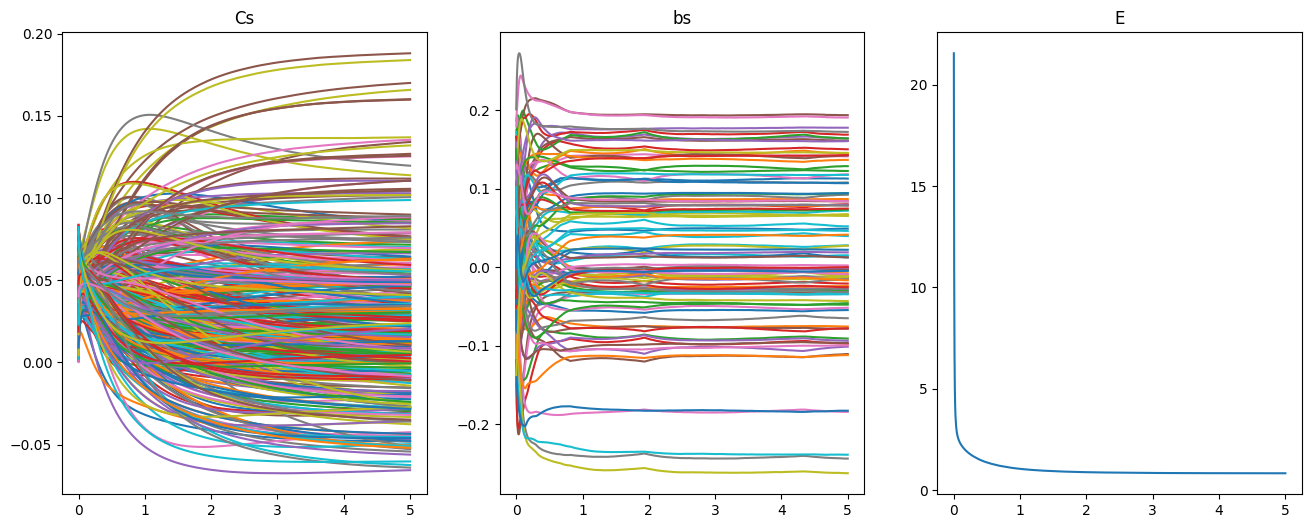

In [12]:
#print(f"Final b =\n{b_f}")
#print(f"Final C =\n{C_f}")
#print(f"Energy: {Es[-1]}")
#print(f"Energy deviation =\n{Es[-1]-E_exact}")
print(f"Final energy: {Es[-1]}")

#print(f"Overlap matrix for final b:\n{b_f.T@b_f}")
print(f"Max overlap coeff (ideally zero): {np.abs(np.max(b_f.T@b_f-np.eye(num_mctdhf_orbitals)))}")


b_arr = np.array(bs)
Es = np.array(Es)
Cs = np.array(Cs)

fig, axs = plt.subplots(1, 3, figsize=(16,6))
axs[0].plot(t, np.real(Cs))
axs[0].set_title('Cs')
axs[1].plot(t, np.real(b_arr.reshape(b_arr.shape[0],*b_init.shape)[:,:,0]))
axs[1].set_title('bs')
#ax[2].plot(t, E_exact*np.ones_like(Es), 'k--')
axs[2].plot(t, np.real(Es))
axs[2].set_title('E')

# for ax in axs:
#     ax.set_xlim(right=t_final)

plt.show()

In [13]:
D = dCI.get_1p_RDM(C_f.reshape(num_mctdhf_alpha_dets, num_mctdhf_beta_dets))

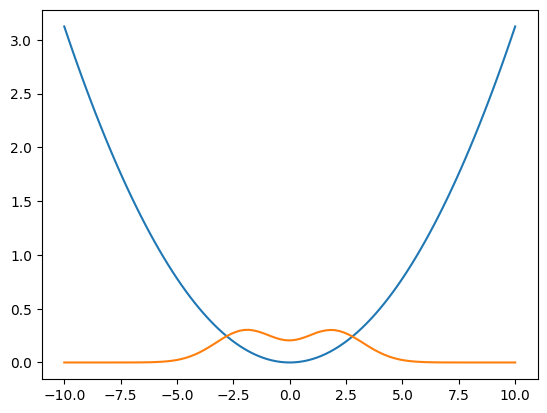

In [14]:
plt.plot(x, pot(x))
plt.plot(x, np.real(np.diag(spf.T@(b_f@D@b_f.T)@spf)))
plt.show()

In [15]:
class MCDTHF:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spatial_orbitals, num_alpha_electrons, num_beta_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spatial_orbitals = num_spatial_orbitals

        num_alpha_dets = int(comb(num_mctdhf_orbitals, num_alpha_electrons))
        num_beta_dets = int(comb(num_mctdhf_orbitals, num_beta_electrons))
        self.num_slater_dets = num_alpha_dets*num_beta_dets
        self.C_shape = (num_alpha_dets, num_beta_dets)

        self.dCI = SemiDirectCI(self.num_mctdhf_orbitals, 
                                num_alpha_electrons, 
                                num_beta_electrons)
        
    @partial(jit, static_argnums=0)
    def __call__(self, t, y):
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spatial_orbitals, self.num_slater_dets)
        bc = b.conj()

        h_1 = contract('jm, ij -> im', b, self.h(t), backend='jax')
        h_2 = contract('in, im -> nm', bc, h_1, backend='jax')
        h_3 = contract('in, nm -> im', b, h_2, backend='jax')

        g_2 = contract('jq, js, ij -> iqs', bc, b, self.g, backend='jax')
        g_3 = contract('ir, iqs -> iqrs', b, g_2, backend='jax')
        g_4 = contract('ip, iqrs -> pqrs', bc, g_3, backend='jax')
        g_5 = contract('ip, pqrs -> iqrs', b, g_4, backend='jax')

        D, d = self.dCI.get_RDMs(jnp.reshape(C, self.C_shape))
        #D_inv = np.linalg.pinv(D)
        # Regularize
        #eps = 1e-10
        #D_reg = D + eps*expm(-D/eps)
        D_inv = jnp.linalg.pinv(D)#_reg)
        #D_inv = pinvh(D_reg)
      
        b_dot = -1j*(h_1 - h_3 + contract('np, pqrs, iqrs -> in', D_inv, d, g_3-g_5, backend='jax'))

        #sigma = self.dCI.get_sigma_equal_spins(C.reshape(self.C_shape)).flatten()
        sigma = self.dCI.get_sigma(jnp.reshape(C, self.C_shape), h_2, g_4).flatten()

        ## "Renormalization" from (127) in Beck et al. rewritten to direct CI
        #E = self.dCI.calculate_energy_from_RDMs(D,d)
        #C_dot = -(sigma-E*C) 

        C_dot = -1j*sigma

        return Cb_to_y(C_dot, b_dot)

In [16]:
@partial(jit, static_argnums=(1,2,3,4))
def h_t(t, h=h, x=grid, eps=1, omega = 8*0.25):
    return h + jnp.diag(x)*jnp.sin(omega*t)

### Scipy integrator

In [35]:
dtype = jnp.complex64
mctdhf_fun = MCDTHF(h_t, jnp.array(g, dtype),
                    num_mctdhf_orbitals, num_sinc_orbitals, 
                    num_alpha_electrons, num_beta_electrons)

y_init = Cb_to_y(C_f, b_f)

Cs_rt = [C_f]
bs_rt = [b_f]

Es_rt = [Es[-1]]

t_init = 0
t_final = 3.0
solver = DOP853(mctdhf_fun, t_init, y_init, t_final, max_step = 1e-2)
#solver = RK45(mctdhf_fun, t_init, y_init, t_final, max_step = 1e-2)
#solver = RK23(mctdhf_fun, t_init, y_init, t_final, max_step = 0.001)

while solver.status == 'running':
    msg = solver.step()

    C, b = y_to_Cb(solver.y, num_mctdhf_orbitals, num_sinc_orbitals, num_mctdhf_dets)
    
    # Is normalizing necessary here?
    #C = normalize_C(C)
    #b = gram_schmidt(b)
    #b = overlap_ortnorm(b)
 
    E = get_E(dCI, h, g, b, C, C_shape)

    Es_rt.append(E)
    Cs_rt.append(C)
    bs_rt.append(b)

    solver.y = Cb_to_y(C, b)
else:
    if solver.status != 'finished':
        raise(RuntimeError(msg))
    
t = np.linspace(t_init, solver.t, len(Cs_rt))

### Øyvind integrator

In [17]:
dtype = jnp.complex64
mctdhf_fun = MCDTHF(h_t, jnp.array(g, dtype),
                    num_mctdhf_orbitals, num_sinc_orbitals, 
                    num_alpha_electrons, num_beta_electrons)
dt = 5e-3
#num_steps = 400
num_steps = int(4*2*np.pi/(0.25*8*dt))


rk4 = get_runge_kutta_4_solver(mctdhf_fun, dt)

y = Cb_to_y(C_f, b_f)

Cs_rt = [C_f]
bs_rt = [b_f]

Es_rt = [Es[-1]]

t = 0
for i in range(num_steps):
    t, y = rk4(t, y)
    C, b = y_to_Cb(y, num_mctdhf_orbitals, num_sinc_orbitals, num_mctdhf_dets)
    
    # Is normalizing necessary here?
    #C = normalize_C(C)
    #b = gram_schmidt(b)
    #b = overlap_ortnorm(b)
 
    E = get_E(dCI, h_t(dt*i), g, b, C, C_shape)

    Es_rt.append(E)
    Cs_rt.append(C)
    bs_rt.append(b)

    y = Cb_to_y(C, b)

t = np.linspace(0, dt*num_steps, len(Cs_rt))

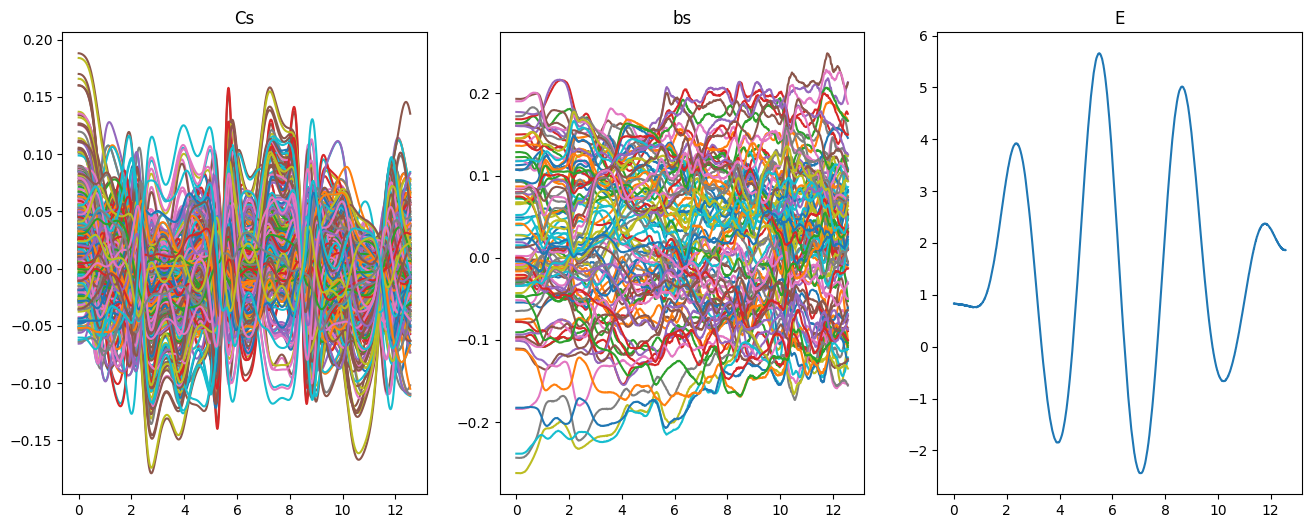

In [18]:
Es_rt = np.array(Es_rt)
Cs_rt = np.array(Cs_rt)
b_arr = np.array(bs_rt)


fig, ax = plt.subplots(1, 3, figsize=(16,6))
ax[0].plot(t, np.real(Cs_rt))
ax[0].set_title('Cs')
ax[1].plot(t, np.real(b_arr.reshape(b_arr.shape[0],*b_init.shape)[:,:,0]))
ax[1].set_title('bs')
#ax[2].plot(t, E_exact*np.ones_like(Es_rt), 'k--')
ax[2].plot(t, np.real(Es_rt))
ax[2].set_title('E')
plt.show()

In [21]:
from jax import jit
I_alpha = dCI.get_slater_dets(num_mctdhf_orbitals, num_alpha_electrons)
@jit
def calculate_overlap(b2,C2,b1=b_f,C1=C_f.reshape(C_shape), I_alpha=I_alpha):
    S = jnp.zeros(C1.shape, np.complex64)
    for i, I_a in enumerate(I_alpha):
        for j, J_a in enumerate(I_alpha):
            s = contract('ki,kj->ij', b1[:,I_a], b2[:,J_a], backend='jax')
            S = S.at[i,j].set(jnp.linalg.det(s))
    return contract('ik,jl,ij,kl',C1.conj(),C2,S,S, backend='jax')

In [42]:
test = []
for I_a in I_alpha:
    test.append(contract('ki,kj->ij', b_f[:,I_a], b[:,I_a])[0,0])
print(np.array(test))
print(contract('ai,ki,kj,aj->a', I_alpha, b_f, b, I_alpha))


[0.62755907+0.18587968j 0.308415  +0.3280907j  0.21360752+0.20013312j
 0.45511058+0.24762756j 0.54177856+0.2379952j  0.4516633 +0.23487458j
 0.6660626 +0.20454651j 0.46239573+0.46950978j 0.65527415+0.13064492j
 0.2787587 -0.05860053j 0.4531344 +0.36547232j 0.54977095+0.0393073j
 0.32947028+0.08419731j 0.36635065+0.13142769j 0.36974448+0.15637702j
 0.25350624+0.31919938j 0.27937233+0.02061767j 0.63369155+0.26393732j
 0.14075322+0.33416295j 0.13477154+0.23047253j]
[0.6275591 +0.18587969j 0.30841494+0.32809073j 0.2136075 +0.20013316j
 0.45511058+0.24762757j 0.5417785 +0.23799518j 0.45166323+0.23487459j
 0.6660626 +0.20454648j 0.4623958 +0.46950975j 0.65527415+0.13064493j
 0.27875867-0.05860057j 0.45313433+0.3654723j  0.5497709 +0.03930729j
 0.3294703 +0.08419731j 0.3663507 +0.1314277j  0.3697445 +0.15637703j
 0.2535063 +0.31919938j 0.2793723 +0.02061767j 0.6336914 +0.26393735j
 0.14075324+0.3341629j  0.13477153+0.23047258j]


In [22]:
overlap = [calculate_overlap(b, C.reshape(C_shape)) for b,C in zip(b_arr, Cs_rt)]

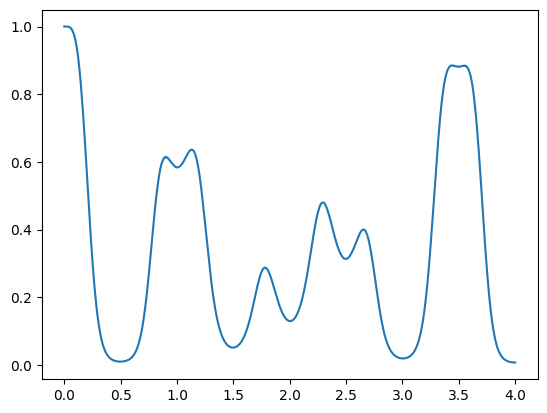

In [23]:
plt.plot(t*0.25*8/(2*np.pi), np.abs(overlap)**2)
plt.show()